In [1]:
import os
import ast
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score, precision_score, recall_score, 
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

os.makedirs('ErrorAnalysis', exist_ok=True)
print("Error Analysis for PCL Classification")

Error Analysis for PCL Classification


In [2]:
print("Loading data and predictions...")

# Load main data
pcl_df = pd.read_csv(
    'dontpatronizeme_pcl.tsv', sep='\t', skiprows=4,
    names=['par_id', 'art_id', 'keyword', 'country_code', 'text', 'orig_label']
)
pcl_df['text'] = pcl_df['text'].fillna('').astype(str)
pcl_df['par_id'] = pcl_df['par_id'].astype(str)

def parse_label(label_str):
    try:
        if isinstance(label_str, str):
            label_list = ast.literal_eval(label_str)
        else:
            label_list = label_str
        return 1 if any(label_list) else 0
    except:
        return 0

# Load dev labels
dev_labels_df = pd.read_csv('dev.csv')
dev_labels_df['binary_label'] = dev_labels_df['label'].apply(parse_label)
dev_labels_df['par_id'] = dev_labels_df['par_id'].astype(str)

# Merge
dev_df = dev_labels_df.merge(
    pcl_df[['par_id', 'art_id', 'keyword', 'country_code', 'text']], 
    on='par_id', how='left'
).dropna(subset=['text'])
dev_df = dev_df[dev_df['text'].str.strip().str.len() > 0].reset_index(drop=True)

print(f"Dev set: {len(dev_df)} samples")
print(f"  PCL: {(dev_df['binary_label']==1).sum()}")
print(f"  No PCL: {(dev_df['binary_label']==0).sum()}")

# Load predictions
# Best model
with open('BestModel_dupe/dev.txt', 'r') as f:
    best_preds = np.array([int(line.strip()) for line in f.readlines()])

# Baseline model
with open('BaselineModel/dev_baseline.txt', 'r') as f:
    baseline_preds = np.array([int(line.strip()) for line in f.readlines()])

# Ground truth
y_true = dev_df['binary_label'].values

print(f"\nPredictions loaded:")
print(f"  Best model:     {best_preds.sum()} PCL predicted")
print(f"  Baseline model: {baseline_preds.sum()} PCL predicted")
print(f"  Ground truth:   {y_true.sum()} actual PCL")

Loading data and predictions...
Dev set: 2093 samples
  PCL: 199
  No PCL: 1894

Predictions loaded:
  Best model:     205 PCL predicted
  Baseline model: 411 PCL predicted
  Ground truth:   199 actual PCL


In [3]:
print("Overall Comparison of both models.")

# Calculate metrics for both models
def calculate_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'F1': f1_score(y_true, y_pred, pos_label=1),
        'Precision': precision_score(y_true, y_pred, pos_label=1),
        'Recall': recall_score(y_true, y_pred, pos_label=1),
        'PCL Predicted': y_pred.sum(),
        'Accuracy': (y_true == y_pred).mean()
    }

metrics_best = calculate_metrics(y_true, best_preds, 'Best Model')
metrics_baseline = calculate_metrics(y_true, baseline_preds, 'Baseline')

comparison_df = pd.DataFrame([metrics_baseline, metrics_best])
print("\nModel Comparison:")
print(comparison_df.to_string(index=False))

# Improvement
improvement = (metrics_best['F1'] - metrics_baseline['F1']) / metrics_baseline['F1'] * 100
print(f"\nF1 Improvement: +{improvement:.1f}%")

# Save comparison
comparison_df.to_csv('ErrorAnalysis/model_comparison.csv', index=False)

Overall Comparison of both models.

Model Comparison:
     Model       F1  Precision   Recall  PCL Predicted  Accuracy
  Baseline 0.422951   0.313869 0.648241            411  0.831820
Best Model 0.648515   0.639024 0.658291            205  0.932155

F1 Improvement: +53.3%


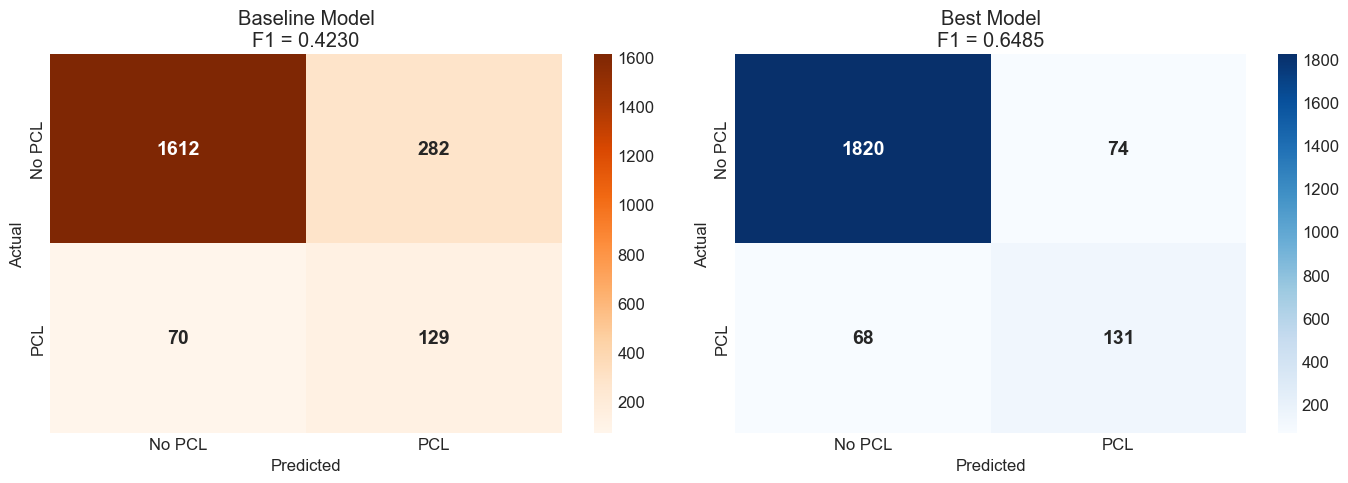


Baseline Confusion Matrix:
  TN: 1612, FP: 282
  FN: 70, TP: 129

Best Model Confusion Matrix:
  TN: 1820, FP: 74
  FN: 68, TP: 131


In [4]:
# Confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline
cm_baseline = confusion_matrix(y_true, baseline_preds)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['No PCL', 'PCL'], yticklabels=['No PCL', 'PCL'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f"Baseline Model\nF1 = {metrics_baseline['F1']:.4f}")

# Best model
cm_best = confusion_matrix(y_true, best_preds)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No PCL', 'PCL'], yticklabels=['No PCL', 'PCL'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f"Best Model\nF1 = {metrics_best['F1']:.4f}")

plt.tight_layout()
plt.savefig('ErrorAnalysis/confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print confusion matrix details
print("\nBaseline Confusion Matrix:")
print(f"  TN: {cm_baseline[0,0]}, FP: {cm_baseline[0,1]}")
print(f"  FN: {cm_baseline[1,0]}, TP: {cm_baseline[1,1]}")

print("\nBest Model Confusion Matrix:")
print(f"  TN: {cm_best[0,0]}, FP: {cm_best[0,1]}")
print(f"  FN: {cm_best[1,0]}, TP: {cm_best[1,1]}")

Error categorisation...

Error Categories:
category
A: Both Correct (TN)        1587
A: Both Correct (TP)         102
B: Best Only Correct         262
C: Baseline Only Correct      52
D: Both Wrong (FN)            41
D: Both Wrong (FP)            49
Name: count, dtype: int64


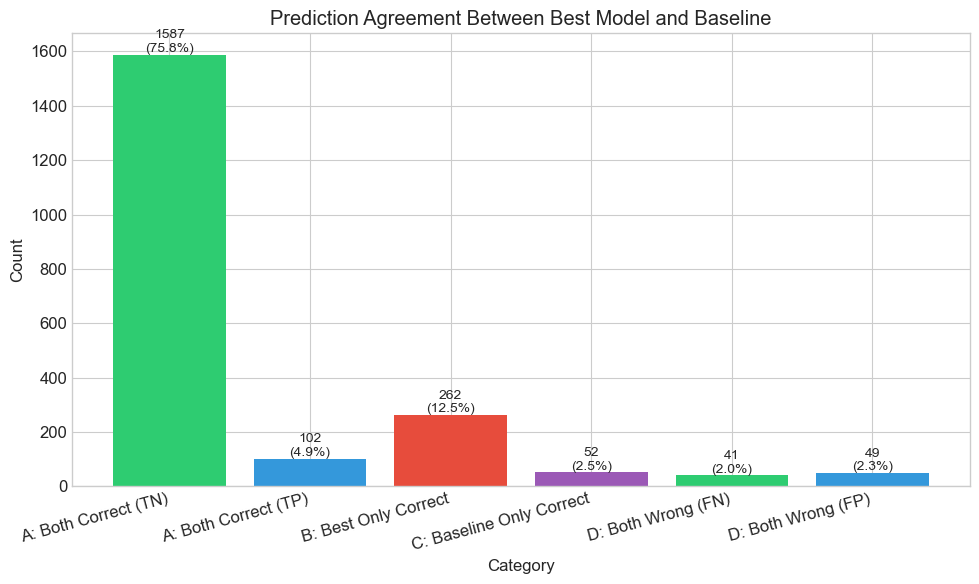

In [5]:
print("Error categorisation...")

# Create analysis dataframe
analysis_df = dev_df.copy()
analysis_df['true_label'] = y_true
analysis_df['best_pred'] = best_preds
analysis_df['baseline_pred'] = baseline_preds

# Categorise samples
def categorize(row):
    true = row['true_label']
    best = row['best_pred']
    baseline = row['baseline_pred']
    
    if true == 1:  # Actual PCL
        if best == 1 and baseline == 1:
            return 'A: Both Correct (TP)'
        elif best == 1 and baseline == 0:
            return 'B: Best Only Correct'
        elif best == 0 and baseline == 1:
            return 'C: Baseline Only Correct'
        else:
            return 'D: Both Wrong (FN)'
    else:  # Actual No PCL
        if best == 0 and baseline == 0:
            return 'A: Both Correct (TN)'
        elif best == 0 and baseline == 1:
            return 'B: Best Only Correct'
        elif best == 1 and baseline == 0:
            return 'C: Baseline Only Correct'
        else:
            return 'D: Both Wrong (FP)'

analysis_df['category'] = analysis_df.apply(categorize, axis=1)

# Count categories
category_counts = analysis_df['category'].value_counts().sort_index()
print("\nError Categories:")
print(category_counts)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
bars = ax.bar(category_counts.index, category_counts.values, color=colors)
ax.set_ylabel('Count')
ax.set_xlabel('Category')
ax.set_title('Prediction Agreement Between Best Model and Baseline')

for bar, count in zip(bars, category_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            f'{count}\n({count/len(analysis_df)*100:.1f}%)', 
            ha='center', fontsize=10)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('ErrorAnalysis/error_categories.png', dpi=300, bbox_inches='tight')
plt.show()

# Save
analysis_df.to_csv('ErrorAnalysis/categorized_predictions.csv', index=False)

In [6]:
print("Analysis of missed PCL samples (false negatives)...")

# Get False Negatives for best model
fn_best = analysis_df[(analysis_df['true_label'] == 1) & (analysis_df['best_pred'] == 0)]
fn_baseline = analysis_df[(analysis_df['true_label'] == 1) & (analysis_df['baseline_pred'] == 0)]

print(f"False Negatives (Missed PCL):")
print(f"  Best Model:     {len(fn_best)} ({len(fn_best)/y_true.sum()*100:.1f}% of PCL)")
print(f"  Baseline Model: {len(fn_baseline)} ({len(fn_baseline)/y_true.sum()*100:.1f}% of PCL)")

# Show examples of False Negatives that both models missed
both_fn = analysis_df[analysis_df['category'] == 'D: Both Wrong (FN)']
print(f"\nBoth models missed {len(both_fn)} PCL samples")

print("PCL samples that both models missed")
print("-"*70)
for i, (_, row) in enumerate(both_fn.head(5).iterrows()):
    print(f"\n[{i+1}] Keyword: {row['keyword']}")
    print(f"    Text: {row['text'][:300]}...")

# Samples only baseline missed but best model caught
best_caught = analysis_df[
    (analysis_df['true_label'] == 1) & 
    (analysis_df['best_pred'] == 1) & 
    (analysis_df['baseline_pred'] == 0)
]
print(f"\n" + "-"*70)
print(f"PCL samples Best Model caught but Baseline model missed ({len(best_caught)} total)")
print("-"*70)
for i, (_, row) in enumerate(best_caught.head(5).iterrows()):
    print(f"\n[{i+1}] Keyword: {row['keyword']}")
    print(f"    Text: {row['text'][:300]}...")

Analysis of missed PCL samples (false negatives)...
False Negatives (Missed PCL):
  Best Model:     68 (34.2% of PCL)
  Baseline Model: 70 (35.2% of PCL)

Both models missed 41 PCL samples
PCL samples that both models missed
----------------------------------------------------------------------

[1] Keyword: hopeless
    Text: We also know that they can benefit by receiving counseling from someone who can help them understand that their feelings are normal and that their situation is not hopeless ; someone who can help them put their situation in perspective and help them communicate with others who could provide support ...

[2] Keyword: refugee
    Text: Many refugees do n't want to be resettled anywhere , let alone in the US ....

[3] Keyword: immigrant
    Text: Many celebrities wore blue ribbons to support the American Civil Liberties Union , which is seeking to shed light on the plight of young immigrants facing the potential of being deported ....

[4] Keyword: immigrant
    Tex

In [7]:
print("Analysis of wrong PCL predictions (false positives)...")

# Get False Positives
fp_best = analysis_df[(analysis_df['true_label'] == 0) & (analysis_df['best_pred'] == 1)]
fp_baseline = analysis_df[(analysis_df['true_label'] == 0) & (analysis_df['baseline_pred'] == 1)]

print(f"False Positives (Wrong PCL predictions):")
print(f"  Best Model:     {len(fp_best)}")
print(f"  Baseline Model: {len(fp_baseline)}")

# Show examples of False Positives
both_fp = analysis_df[analysis_df['category'] == 'D: Both Wrong (FP)']
print(f"\nBoth models wrongly predicted {len(both_fp)} samples as PCL")

print("\n" + "-"*70)
print("Non-PCL samples both models wrongly predicted as PCL")
print("-"*70)
for i, (_, row) in enumerate(both_fp.head(5).iterrows()):
    print(f"\n[{i+1}] Keyword: {row['keyword']}")
    print(f"    Text: {row['text'][:300]}...")

Analysis of wrong PCL predictions (false positives)...
False Positives (Wrong PCL predictions):
  Best Model:     74
  Baseline Model: 282

Both models wrongly predicted 49 samples as PCL

----------------------------------------------------------------------
Non-PCL samples both models wrongly predicted as PCL
----------------------------------------------------------------------

[1] Keyword: poor-families
    Text: Marcos said the government should help poor families that try every possible means to survive . With Joel Zurbano <h> More from this Category :...

[2] Keyword: homeless
    Text: " The proceeds from Lady Lucan 's estate will help Shelter to continue fighting bad housing and homelessness . "...

[3] Keyword: homeless
    Text: As leaders , we will personally support victims but we ask the government to also help . We are going to clear all victims ' hospital bills and we want to ensure that those left homeless receive shelter ....

[4] Keyword: homeless
    Text: His frie


Performance by Keyword (sorted by improvement):
      Keyword  Total  PCL  Best Recall  Baseline Recall  Improvement
poor-families    190   38     0.736842         0.526316     0.210526
      migrant    206    5     0.600000         0.400000     0.200000
      refugee    188   13     0.692308         0.538462     0.153846
    immigrant    218    7     0.428571         0.285714     0.142857
      in-need    226   33     0.757576         0.696970     0.060606
     hopeless    217   26     0.615385         0.653846    -0.038462
   vulnerable    209   20     0.700000         0.750000    -0.050000
     homeless    212   29     0.620690         0.689655    -0.068966
     disabled    194   14     0.642857         0.857143    -0.214286
        women    233   14     0.428571         0.785714    -0.357143


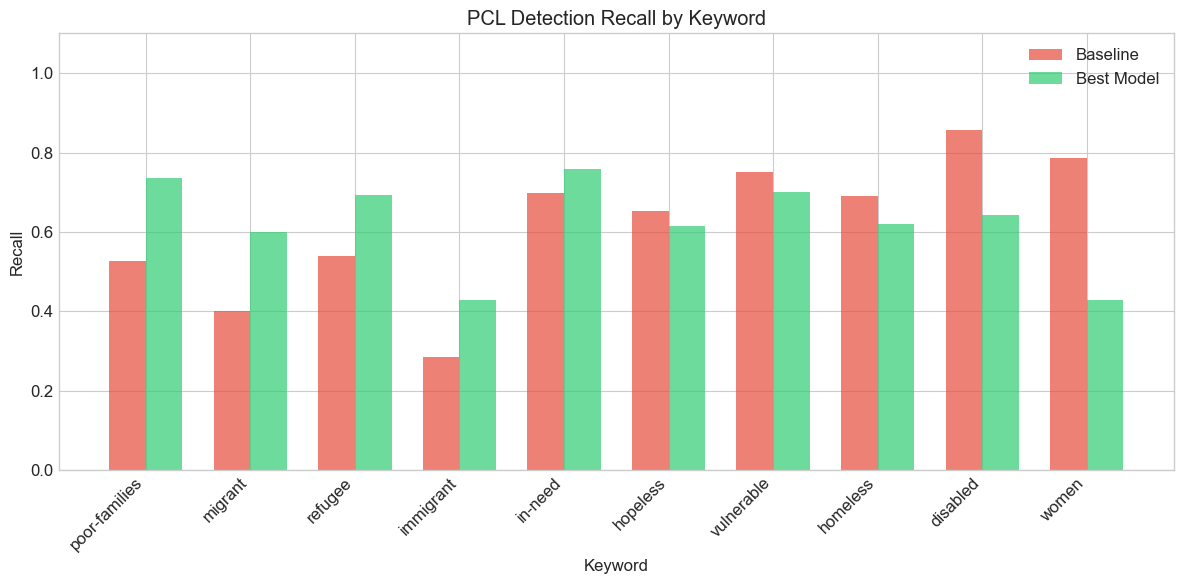

In [8]:
# Analyze performance by keyword
keyword_analysis = []

for keyword in analysis_df['keyword'].unique():
    keyword_data = analysis_df[analysis_df['keyword'] == keyword]
    
    n_samples = len(keyword_data)
    n_pcl = (keyword_data['true_label'] == 1).sum()
    
    if n_pcl > 0:
        # Best model
        best_tp = ((keyword_data['true_label'] == 1) & (keyword_data['best_pred'] == 1)).sum()
        best_recall = best_tp / n_pcl
        
        # Baseline
        baseline_tp = ((keyword_data['true_label'] == 1) & (keyword_data['baseline_pred'] == 1)).sum()
        baseline_recall = baseline_tp / n_pcl
        
        keyword_analysis.append({
            'Keyword': keyword,
            'Total': n_samples,
            'PCL': n_pcl,
            'Best Recall': best_recall,
            'Baseline Recall': baseline_recall,
            'Improvement': best_recall - baseline_recall
        })

keyword_df = pd.DataFrame(keyword_analysis).sort_values('Improvement', ascending=False)

print("\nPerformance by Keyword (sorted by improvement):")
print(keyword_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(keyword_df))
width = 0.35

bars1 = ax.bar(x - width/2, keyword_df['Baseline Recall'], width, label='Baseline', color='#e74c3c', alpha=0.7)
bars2 = ax.bar(x + width/2, keyword_df['Best Recall'], width, label='Best Model', color='#2ecc71', alpha=0.7)

ax.set_ylabel('Recall')
ax.set_xlabel('Keyword')
ax.set_title('PCL Detection Recall by Keyword')
ax.set_xticks(x)
ax.set_xticklabels(keyword_df['Keyword'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('ErrorAnalysis/recall_by_keyword.png', dpi=300, bbox_inches='tight')
plt.show()

# Save
keyword_df.to_csv('ErrorAnalysis/keyword_analysis.csv', index=False)

Precision-Recall curve...


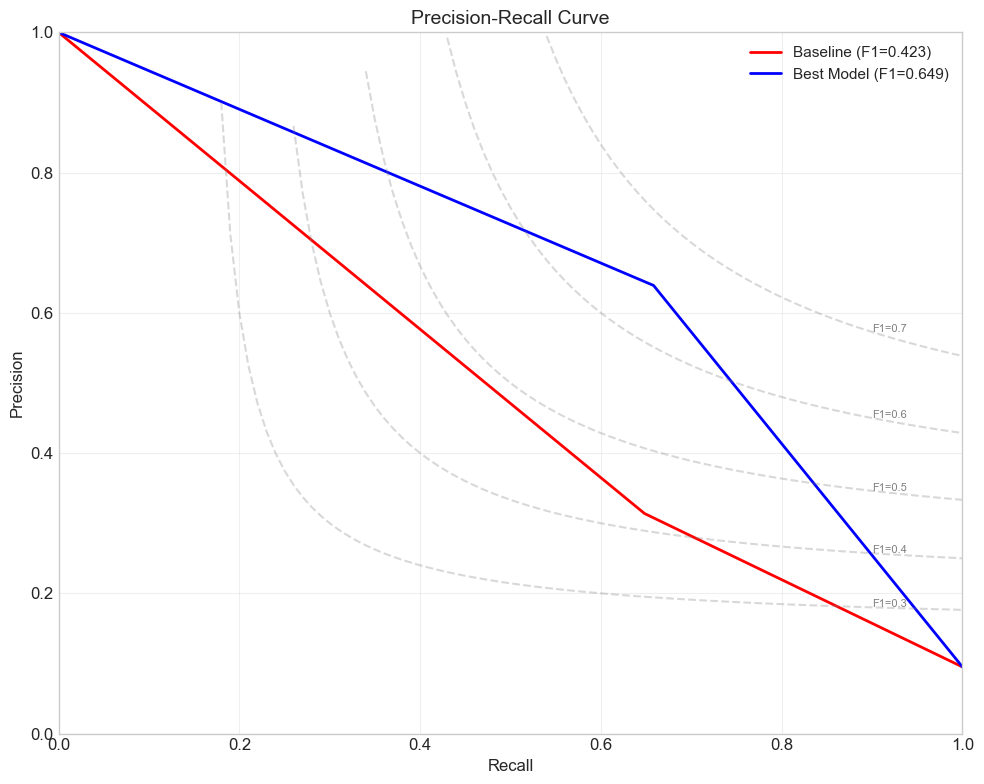

In [9]:
print("Precision-Recall curve...")
dev_probs_best = best_preds.astype(float)
dev_probs_baseline = baseline_preds.astype(float)

# Calculate PR curves
precision_best, recall_best, thresholds_best = precision_recall_curve(y_true, dev_probs_best)
precision_baseline, recall_baseline, thresholds_baseline = precision_recall_curve(y_true, dev_probs_baseline)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(recall_baseline, precision_baseline, 'r-', linewidth=2, label=f'Baseline (F1={metrics_baseline["F1"]:.3f})')
ax.plot(recall_best, precision_best, 'b-', linewidth=2, label=f'Best Model (F1={metrics_best["F1"]:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=14)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Add F1 iso-lines
for f1 in [0.3, 0.4, 0.5, 0.6, 0.7]:
    x = np.linspace(0.01, 1, 100)
    y = f1 * x / (2 * x - f1)
    y[y < 0] = np.nan
    y[y > 1] = np.nan
    ax.plot(x, y, '--', color='gray', alpha=0.3)
    # Label the iso-line
    idx = np.argmin(np.abs(x - 0.9))
    if not np.isnan(y[idx]):
        ax.annotate(f'F1={f1}', xy=(x[idx], y[idx]), fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('ErrorAnalysis/precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
print("Error analysis completed. Summary: ")

summary = f"""
ERROR ANALYSIS SUMMARY
----------------------

1. OVERALL PERFORMANCE
   - Best Model F1:     {metrics_best['F1']:.4f}
   - Baseline F1:       {metrics_baseline['F1']:.4f}
   - Improvement:       +{improvement:.1f}%

2. ERROR DISTRIBUTION
   - Both models correct:       {(analysis_df['category'].str.startswith('A')).sum()}
   - Best only correct:         {(analysis_df['category'] == 'B: Best Only Correct').sum()}
   - Baseline only correct:     {(analysis_df['category'] == 'C: Baseline Only Correct').sum()}
   - Both models wrong:         {(analysis_df['category'].str.startswith('D')).sum()}

3. FALSE NEGATIVES (Missed PCL)
   - Best Model:     {len(fn_best)} ({len(fn_best)/y_true.sum()*100:.1f}% of PCL)
   - Baseline:       {len(fn_baseline)} ({len(fn_baseline)/y_true.sum()*100:.1f}% of PCL)

4. FALSE POSITIVES (Wrong PCL predictions)
   - Best Model:     {len(fp_best)}
   - Baseline:       {len(fp_baseline)}

5. KEY INSIGHTS
   - Best model catches {len(best_caught)} more PCL samples than baseline
   - Both models struggle with subtle/implicit PCL
   - Some keywords (e.g., {keyword_df.iloc[0]['Keyword']}) show biggest improvement

"""

print(summary)


Error analysis completed. Summary: 

ERROR ANALYSIS SUMMARY
----------------------

1. OVERALL PERFORMANCE
   - Best Model F1:     0.6485
   - Baseline F1:       0.4230
   - Improvement:       +53.3%

2. ERROR DISTRIBUTION
   - Both models correct:       1689
   - Best only correct:         262
   - Baseline only correct:     52
   - Both models wrong:         90

3. FALSE NEGATIVES (Missed PCL)
   - Best Model:     68 (34.2% of PCL)
   - Baseline:       70 (35.2% of PCL)

4. FALSE POSITIVES (Wrong PCL predictions)
   - Best Model:     74
   - Baseline:       282

5. KEY INSIGHTS
   - Best model catches 29 more PCL samples than baseline
   - Both models struggle with subtle/implicit PCL
   - Some keywords (e.g., poor-families) show biggest improvement


